# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 9125985)
3. Arya (ID: 9084843)

**Research Question:** How are temperature and season associated with daily Capital Bikeshare rental demand?



## Use Case and Context

Bike-sharing operators need to understand how rental demand changes under different weather conditions and seasons. Knowing these patterns can help them make better decisions about **bike availability, maintenance, and daily operations**.

In this project, we analyze historical **Capital Bikeshare** data to study how **temperature and season are associated with daily bike rental demand**. The dataset contains **731 daily records from 2011–2012**, including information such as daily rental counts, temperature, humidity, and season.

By using descriptive statistics and visualizations, we can identify historical patterns, such as whether rental demand tends to be higher or lower at different temperatures and during different seasons. This analysis focuses on **understanding past relationships rather than predicting future demand or proving that weather directly causes changes in rentals**.

## Data Source

**Source:** Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository.  
https://doi.org/10.24432/C5W894

The dataset contains **731 daily bike rental records from 2011 to 2012**. Each row represents one day.

For our analysis, we mainly use:
- `cnt` – total number of daily rentals
- `temp` – normalized temperature
- `hum` – normalized humidity
- `season` – season of the year

The `day.csv` file is stored in the project's `data` folder and loaded using pandas.

## Questions Considered When Choosing the Data

- **Does the dataset contain enough observations?**  
  Yes. The dataset contains 731 daily observations covering 2011–2012.

- **Does it contain numerical variables suitable for statistical analysis?**  
  Yes. It includes temperature, humidity, and total rental counts.

- **Does the data relate to our research question?**  
  Yes. The dataset contains temperature, season, and total rental demand, which are the variables required for our analysis.

- **Is the dataset available in a usable format?**  
  Yes. The Bike Sharing Dataset provides the daily observations in CSV format.

In [1]:

# Libraries used for data analysis and visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2
from scipy import stats

## Data Checks and Cleansing

Before analyzing the data, we check that the dataset is accurate and ready to use.

We:
- Check for missing values and duplicate dates.
- Verify that the season codes are valid.
- Verify that total rentals equal casual rentals + registered rentals.
- Convert temperature to Celsius.
- Convert humidity to percentage.
- Convert season codes into readable season names such as Winter, Spring, Summer, and Fall.
- Remove duplicate rows if any are found.


### Loading the Bike Sharing Dataset

We use the Bike Sharing Dataset from the UCI Machine Learning Repository.

The dataset contains 731 daily bike rental records from 2011 to 2012.

To make our notebook easier to run on different computers, we first check whether the dataset is available in our project folder.

If the CSV file is not found, our code automatically downloads a copy from our GitHub repository.

This helps all group members run the same analysis without manually changing file paths.


In [2]:
# Load real-world daily bike rental data

# Step 1: Import tools for finding and downloading files
from pathlib import Path
from urllib.request import urlretrieve

# Step 2: Check possible dataset locations
possible_paths = [
    Path("data/day.csv"),
    Path("../data/day.csv")
]

csv_path = next(
    (path for path in possible_paths if path.is_file()),
    None
)

# Step 3: Download the dataset if it is missing
if csv_path is None:
    csv_path = Path("data/day.csv")
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    url = "https://raw.githubusercontent.com/shainaulakh/Data_Analysis_Presentation1/main/data/day.csv"

    urlretrieve(url, csv_path)
    print("Dataset downloaded successfully.")

# Step 4: Load the dataset
df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")

# Data Validation


# Step 1: Check that all required columns are available
required_columns = {
    'dteday',
    'season',
    'temp',
    'hum',
    'cnt',
    'casual',
    'registered'
}

missing_columns = required_columns - set(df.columns)

# Stop only if an important column itself is missing
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")


# Step 2: Convert the date column to datetime format
df['dteday'] = pd.to_datetime(df['dteday'], errors='raise')


# Step 3: Check the dataset for missing values
# We only report them here because the UCI dataset is expected
# to contain no missing values.
missing_values = df.isna().sum().sum()

print(f"Number of rows: {len(df)}")
print(f"Missing values: {missing_values}")


# Step 4: Check for duplicate dates
duplicate_dates = df['dteday'].duplicated().sum()

print(f"Duplicate dates: {duplicate_dates}")


# Step 5: Validate season codes
# UCI defines: 1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall
if not df['season'].isin([1, 2, 3, 4]).all():
    raise ValueError("Unexpected season code found.")


# Step 6: Verify that total rentals are correct
# Total rentals should equal casual rentals + registered rentals
if not (df['casual'] + df['registered'] == df['cnt']).all():
    raise ValueError("Rental totals do not match casual + registered rentals.")



# Data Cleansing and Transformation


# Step 7: Convert normalized temperature to Celsius
df['Temperature_C'] = (df['temp'] * 41).round(1)


# Step 8: Convert normalized humidity to percentage
df['Humidity_Pct'] = (df['hum'] * 100).round(1)


# Step 9: Rename important columns for readability
df.rename(columns={
    'cnt': 'Total_Rentals',
    'workingday': 'Working_Day',
    'season': 'Season_Code'
}, inplace=True)


# Step 10: Convert season codes to meaningful season names
season_map = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

df['Season'] = df['Season_Code'].map(season_map)


# Step 11: Remove duplicate rows if any exist
duplicates_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"Duplicate rows removed: {duplicates_before}")



# Display Cleaned Data


print("\nData successfully validated and cleansed:")

display(
    df[
        [
            'dteday',
            'Season',
            'Temperature_C',
            'Humidity_Pct',
            'Working_Day',
            'Total_Rentals'
        ]
    ].head(10)
)

Dataset loaded successfully.
Number of rows: 731
Missing values: 0
Duplicate dates: 0
Duplicate rows removed: 0

Data successfully validated and cleansed:


,dteday,Season,Temperature_C,Humidity_Pct,Working_Day,Total_Rentals
0,2011-01-01,Winter,14.1,80.6,0,985
1,2011-01-02,Winter,14.9,69.6,0,801
2,2011-01-03,Winter,8.1,43.7,1,1349
3,2011-01-04,Winter,8.2,59.0,1,1562
4,2011-01-05,Winter,9.3,43.7,1,1600
5,2011-01-06,Winter,8.4,51.8,1,1606
6,2011-01-07,Winter,8.1,49.9,1,1510
7,2011-01-08,Winter,6.8,53.6,0,959
8,2011-01-09,Winter,5.7,43.4,0,822
9,2011-01-10,Winter,6.2,48.3,1,1321


## 50-word use case summary

Capital Bikeshare managers need to understand when daily demand rises or falls. We analyze 731 days of rental totals, temperature, and seasons from 2011 to 2012. Descriptive statistics and visualizations show historical associations that may guide fleet planning and maintenance scheduling. They do not provide station-level forecasts or establish causation.


## Numerical Exploration

In this section, we calculate descriptive statistics to better understand the bike rental data.

We calculate:
- **Mean, median, and mode** to understand the typical values.
- **Variance and standard deviation** to understand how much the values vary.
- **Quartiles (Q1–Q4)** to understand how the values are distributed.

Our main focus is **daily bike rentals**, with temperature also analyzed because it is part of our research question.

In [3]:
class BikeDemandAnalyzer:
    """Summarize daily rental demand and the variables in the research question."""

    
    # Step 1: Initialize the Analyzer
   

    def __init__(self, data):
        # Store the cleaned dataset so all methods in this class can use it
        self.data = data


    
    # Step 2: Calculate Statistics for a Numeric Column
    

    def statistics(self, column):
        """Calculate central tendency, spread, and quartiles for a numeric column."""

        # Remove missing values from the selected column before calculation
        values = self.data[column].dropna()

        # Find all modes because a dataset may have more than one mode
        modes = values.mode().tolist()

        # Calculate and return the required descriptive statistics
        return pd.Series({
            "Count": len(values),

            # Measures of central tendency
            "Mean": values.mean(),
            "Median": values.median(),
            "Mode(s)": ", ".join(f"{x:g}" for x in modes),

            # Measures of spread
            "Sample variance": values.var(ddof=1),
            "Sample standard deviation": values.std(ddof=1),

            # Quartiles
            "Q1 (25%)": values.quantile(.25),
            "Q2 (50%)": values.quantile(.50),
            "Q3 (75%)": values.quantile(.75),
            "Q4 (100%; maximum)": values.quantile(1)
        })


    # Step 3: Create Overall and Seasonal Numerical Summaries
  

    def numerical_summary(self):
        """Display overall numerical statistics and seasonal rental summaries."""

        # Select the main numerical variables used in the analysis
        columns = [
            "Total_Rentals",
            "Temperature_C",
            "Humidity_Pct"
        ]

        # Display overall descriptive statistics
        display(
            self.data[columns]
            .describe()
            .round(2)
        )

        # Compare rental demand across the four seasons
        display(
            self.data.groupby("Season")["Total_Rentals"]
            .agg(
                Days="count",
                Mean="mean",
                Median="median",
                Min="min",
                Max="max"
            )
            .reindex(["Winter", "Spring", "Summer", "Fall"])
            .round(2)
        )



# Step 4: Create an Object of the BikeDemandAnalyzer Class


analyzer = BikeDemandAnalyzer(df)



# Step 5: Display Required Statistics


# Calculate statistics for daily rentals and temperature
for variable in ["Total_Rentals", "Temperature_C"]:

    print(f"\n{variable} (rentals/day or °C)")

    display(
        analyzer.statistics(variable)
        .to_frame("Value")
    )



# Step 6: Display Overall and Seasonal Summary


print("\nNumerical summary and seasonal comparison")

analyzer.numerical_summary()


Total_Rentals (rentals/day or °C)


,Value
Count,731
Mean,4504.348837
Median,4548.0
Mode(s),"1096, 1162, 1685, 1977, 2077, 2424, 2425, 3068..."
Sample variance,3752788.208283
Sample standard deviation,1937.211452
Q1 (25%),3152.0
Q2 (50%),4548.0
Q3 (75%),5956.0
Q4 (100%; maximum),8714.0



Temperature_C (rentals/day or °C)


,Value
Count,731
Mean,20.31067
Median,20.4
Mode(s),26.6
Sample variance,56.33016
Sample standard deviation,7.505342
Q1 (25%),13.8
Q2 (50%),20.4
Q3 (75%),26.9
Q4 (100%; maximum),35.3



Numerical summary and seasonal comparison


,Total_Rentals,Temperature_C,Humidity_Pct
count,731.00,731.00,731.00
mean,4504.35,20.31,62.79
std,1937.21,7.51,14.24
min,22.00,2.40,0.00
25%,3152.00,13.80,52.00
50%,4548.00,20.40,62.70
75%,5956.00,26.90,73.00
max,8714.00,35.30,97.20


,Days,Mean,Median,Min,Max
Season,,,,,
Winter,181,2604.13,2209.0,431,7836
Spring,184,4992.33,4941.5,795,8362
Summer,188,5644.30,5353.5,1115,8714
Fall,178,4728.16,4634.5,22,8555


## Four Views of the Data

We use four visualizations to better understand the bike rental data:

- **Scatter Plot:** Shows the relationship between temperature and daily bike rentals.
- **Histogram:** Shows how daily rental totals are distributed.
- **Box Plot:** Compares daily bike rentals across the four seasons.
- **Venn Diagram:** Shows the overlap between high-demand days (more than 5,000 rentals) and warm days (above 20°C).

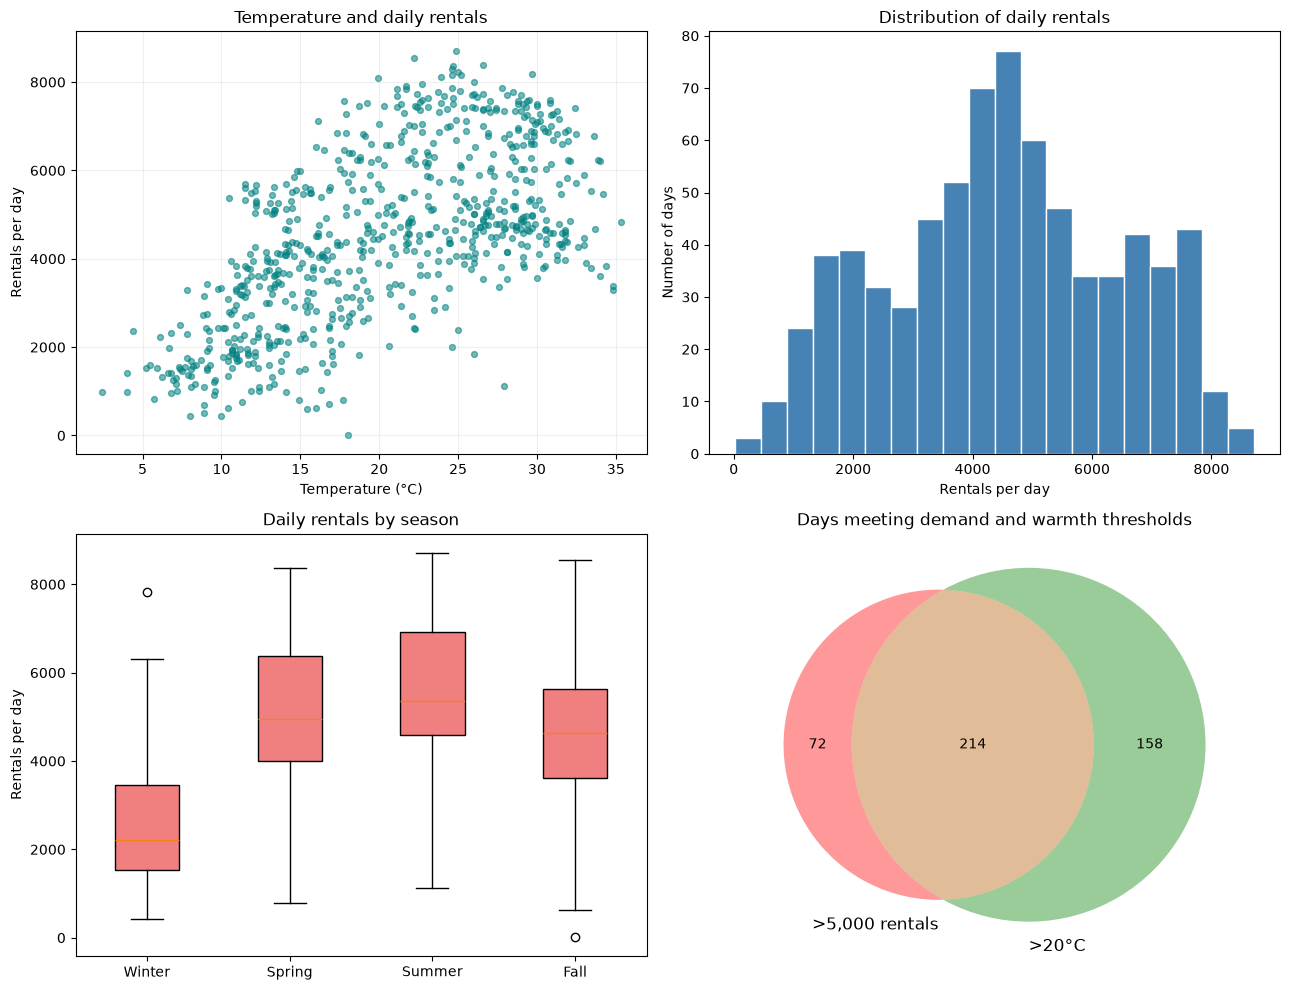

High-demand days: 286; warm days: 372; both: 214


In [4]:
class BikeVisualizer:
    """Create four visualizations for the daily bike rental data."""

    
    # Step 1: Initialize the Visualizer
    

    def __init__(self, data):
        # Store the cleaned dataset so it can be used for plotting
        self.data = data


   
    # Step 2: Create All Four Required Visualizations
    

    def plot_all(self):
        """Create scatter plot, histogram, box plot, and Venn diagram."""

        # Create a 2 x 2 layout for the four visualizations
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))


        
        # Step 3: Scatter Plot - Temperature vs Daily Rentals
       

        # Compare temperature with the total number of daily rentals
        axes[0, 0].scatter(
            self.data.Temperature_C,
            self.data.Total_Rentals,
            alpha=0.55,
            s=18,
            color="teal"
        )

        # Add title and axis labels
        axes[0, 0].set(
            title="Temperature and daily rentals",
            xlabel="Temperature (°C)",
            ylabel="Rentals per day"
        )

        axes[0, 0].grid(alpha=0.2)


        
        # Step 4: Histogram - Distribution of Daily Rentals
        

        # Show how frequently different daily rental totals occur
        axes[0, 1].hist(
            self.data.Total_Rentals,
            bins=20,
            color="steelblue",
            edgecolor="white"
        )

        # Add title and axis labels
        axes[0, 1].set(
            title="Distribution of daily rentals",
            xlabel="Rentals per day",
            ylabel="Number of days"
        )


       
        # Step 5: Box Plot - Compare Rentals Across Seasons
        

        # Define the order of the seasons
        seasons = ["Winter", "Spring", "Summer", "Fall"]

        # Collect rental values separately for each season
        season_values = [
            self.data.loc[
                self.data.Season.eq(season),
                "Total_Rentals"
            ]
            for season in seasons
        ]

        # Create the seasonal box plot
        axes[1, 0].boxplot(
            season_values,
            patch_artist=True,
            boxprops={"facecolor": "lightcoral"}
        )

        # Add season names to the x-axis
        axes[1, 0].set_xticks(range(1, len(seasons) + 1))
        axes[1, 0].set_xticklabels(seasons)

        # Add title and axis label
        axes[1, 0].set(
            title="Daily rentals by season",
            ylabel="Rentals per day"
        )


        
        # Step 6: Venn Diagram - High Demand and Warm Days
        

        # Find days with more than 5,000 rentals
        high = set(
            self.data.index[
                self.data.Total_Rentals.gt(5000)
            ]
        )

        # Find days where temperature was above 20°C
        warm = set(
            self.data.index[
                self.data.Temperature_C.gt(20)
            ]
        )

        # Show the overlap between high-demand days and warm days
        venn2(
            [high, warm],
            set_labels=(">5,000 rentals", ">20°C"),
            ax=axes[1, 1]
        )

        axes[1, 1].set_title(
            "Days meeting demand and warmth thresholds"
        )


        
        # Step 7: Display the Visualizations
        

        # Adjust spacing so the plots do not overlap
        fig.tight_layout()

        # Display all four plots
        plt.show()


       
        # Step 8: Display Venn Diagram Counts
        

        # Print the number of high-demand days, warm days,
        # and days that meet both conditions
        print(
            f"High-demand days: {len(high)}; "
            f"warm days: {len(warm)}; "
            f"both: {len(high & warm)}"
        )



# Step 9: Create the Visualizer Object and Display the Plots


BikeVisualizer(df).plot_all()

## Research Question
 How do daily Capital Bikeshare rentals differ between Winter and Summer in terms of distribution, variability, and average demand?


## Comparing Winter and Summer Rental Distributions

### Why Are We Using Histograms?

A histogram shows how frequently different values appear in our dataset.

We created separate histograms for Winter and Summer to understand how daily bike rentals are distributed in each season.

These graphs help us visually check whether the rental data looks approximately bell-shaped (normally distributed).

We can compare these graphs with our Shapiro-Wilk test results to better understand the distribution of bike rentals.


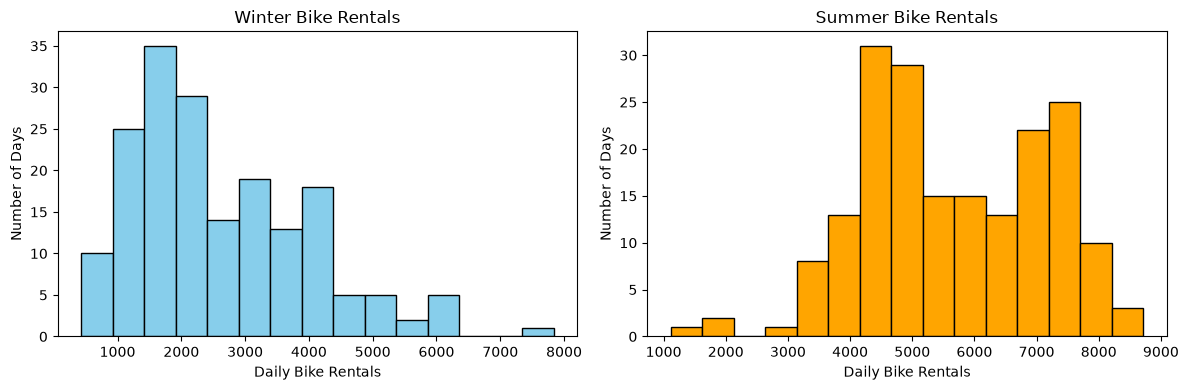

In [5]:

# Step 1: Select Winter and Summer rental data
winter = df[df["Season"] == "Winter"]["Total_Rentals"]
summer = df[df["Season"] == "Summer"]["Total_Rentals"]

# Step 2: Create two histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Step 3: Winter histogram
axes[0].hist(winter, bins=15, color="skyblue", edgecolor="black")
axes[0].set_title("Winter Bike Rentals")
axes[0].set_xlabel("Daily Bike Rentals")
axes[0].set_ylabel("Number of Days")

# Step 4: Summer histogram
axes[1].hist(summer, bins=15, color="orange", edgecolor="black")
axes[1].set_title("Summer Bike Rentals")
axes[1].set_xlabel("Daily Bike Rentals")
axes[1].set_ylabel("Number of Days")

# Step 5: Display the graphs
plt.tight_layout()
plt.show()



### Interpretation of Winter and Summer Histograms

The histograms show how daily bike rentals are distributed in Winter and Summer.

**Winter:**
- Most days had around 1,000 to 3,000 rentals.
- A few days had much higher rentals.
- The distribution is right-skewed and does not look like a normal bell curve.

**Summer:**
- Most days had around 4,000 to 8,000 rentals.
- Rental demand was generally higher than in Winter.
- The distribution does not show a clear, symmetrical bell shape.

**Conclusion:**

Both histograms suggest that the rental data may not be normally distributed.

## Normality Analysis of Daily Bike Rentals

We assess whether the `Total_Rentals` variable is approximately normally distributed. The existing histogram provides an initial view of the distribution. We further assess normality using a QQ-plot and the Shapiro-Wilk test.

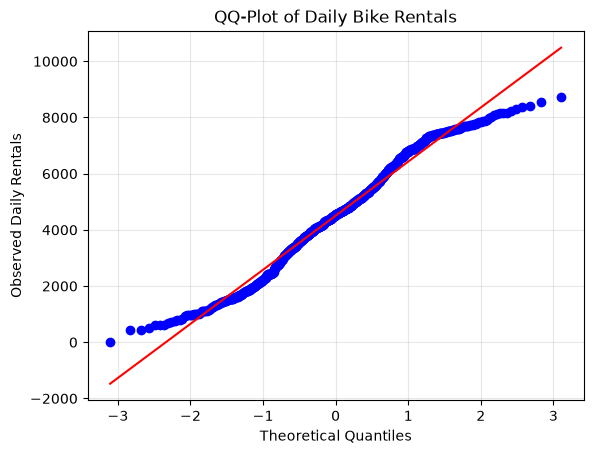

In [6]:
# Select daily rental values for normality analysis
rental_data = df["Total_Rentals"].dropna()

# Create QQ-plot
stats.probplot(rental_data, dist="norm", plot=plt)

plt.title("QQ-Plot of Daily Bike Rentals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Daily Rentals")
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Shapiro-Wilk normality test
shapiro_stat, p_value = stats.shapiro(rental_data)

print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("The data does not appear to be normally distributed.")
else:
    print("The data appears to be approximately normally distributed.")

Shapiro-Wilk Statistic: 0.9801
P-value: 0.000000
The data does not appear to be normally distributed.


### Normality Interpretation

The QQ-plot and Shapiro-Wilk test were used to assess whether daily bike rentals in our dataset are approximately normally distributed. In the QQ-plot, many observations near the middle follow the reference line, but noticeable deviations occur toward both ends. This suggests that the distribution does not completely follow a normal distribution. The Shapiro-Wilk test produced a statistic of 0.9801 and a p-value below 0.05. Therefore, we reject the assumption that daily bike rentals are normally distributed. Both the visual and statistical results indicate departures from normality. This should be considered when selecting and interpreting further statistical tests for this dataset.


## Checking Normality Before the F-Test

### Why Are We Checking Normality?

Before using the F-test, we need to check whether bike rentals in Winter and Summer are approximately normally distributed.

The F-test assumes that the data in each group follows a normal distribution.

We already checked normality for the complete dataset, but now we need to check Winter and Summer separately.

### Shapiro-Wilk Normality Test

We use the Shapiro-Wilk test to check both seasons.

**Hypotheses:**

- **H₀ (Null Hypothesis):** The rental data follows a normal distribution.
- **H₁ (Alternative Hypothesis):** The rental data does not follow a normal distribution.

**Significance Level: 0.05**

- If **p-value < 0.05**, we reject the null hypothesis. The data shows evidence of not being normally distributed.
- If **p-value ≥ 0.05**, we fail to reject the null hypothesis. We do not have enough evidence to say the data is not normal.

This check helps us understand whether the normality assumption of our F-test is reasonable.


In [9]:

# Step 1: Check normality for Winter bike rentals
winter_stat, winter_p = stats.shapiro(winter)

# Step 2: Check normality for Summer bike rentals
summer_stat, summer_p = stats.shapiro(summer)

# Step 3: Display the results
print("Winter Shapiro-Wilk Results")
print("Statistic:", round(winter_stat, 4))
print("P-value:", f"{winter_p:.3e}")

print("\nSummer Shapiro-Wilk Results")
print("Statistic:", round(summer_stat, 4))
print("P-value:", f"{summer_p:.3e}")

# Step 4: Interpret Winter results
if winter_p < 0.05:
    print("\nWinter: Evidence of non-normal distribution.")
else:
    print("\nWinter: No significant departure from normality.")

# Step 5: Interpret Summer results
if summer_p < 0.05:
    print("Summer: Evidence of non-normal distribution.")
else:
    print("Summer: No significant departure from normality.")


Winter Shapiro-Wilk Results
Statistic: 0.938
P-value: 4.983e-07

Summer Shapiro-Wilk Results
Statistic: 0.9632
P-value: 7.679e-05

Winter: Evidence of non-normal distribution.
Summer: Evidence of non-normal distribution.



### Interpretation of Winter and Summer Normality

We used the Shapiro-Wilk test to check whether daily bike rentals in Winter and Summer follow a normal distribution.

**Results:**

- **Winter:** W = 0.9380, p-value = 4.983e-07
- **Summer:** W = 0.9632, p-value = 7.679e-05

Both p-values are below 0.05. Therefore, we reject the null hypothesis of normality for both seasons.

## Variance Analysis

Variance shows how much bike rental demand changes within a group.

A **low variance** means the daily rental values are relatively close to each other, so rental demand is more consistent. A **high variance** means the rental values are more spread out, showing greater changes in demand from day to day.

For this analysis, we compare the variance of bike rentals in **Winter and Summer**. This helps us understand which season has more variation in daily bike rental demand.

In [5]:
# Get Winter and Summer rental data

winter = df[df["Season"] == "Winter"]["Total_Rentals"]
summer = df[df["Season"] == "Summer"]["Total_Rentals"]

# Calculate variance

winter_variance = winter.var()
summer_variance = summer.var()

print("Winter Variance:", round(winter_variance, 2))
print("Summer Variance:", round(summer_variance, 2))

Winter Variance: 1959837.94
Summer Variance: 2131017.15


## F-Test

The F-test is used to determine whether the variances of two groups are significantly different.

In this analysis, we compare the variance of daily bike rentals in **Winter and Summer**.

The test uses the following hypotheses:

- **H₀ (Null Hypothesis):** Winter and Summer have equal variances in bike rental demand.
- **H₁ (Alternative Hypothesis):** Winter and Summer have different variances in bike rental demand.

The F-statistic is calculated by dividing the larger variance by the smaller variance. A value close to 1 means the variances are similar, while a larger F-value suggests a greater difference between them.

In [10]:
from scipy.stats import f

# Calculate F-statistic using larger variance / smaller variance

if summer_variance >= winter_variance:
    f_stat = summer_variance / winter_variance
    df1 = len(summer) - 1
    df2 = len(winter) - 1
else:
    f_stat = winter_variance / summer_variance
    df1 = len(winter) - 1
    df2 = len(summer) - 1

print("F-statistic:", round(f_stat, 2))

F-statistic: 1.09


##  Interpret the P-Value

The p-value helps us determine whether the difference between the Winter and Summer variances is statistically significant.

We use a significance level of **0.05**.

- If **p-value < 0.05**, we reject the null hypothesis. This means Winter and Summer have significantly different variances in bike rental demand.
- If **p-value ≥ 0.05**, we fail to reject the null hypothesis. This means there is not enough evidence to say that their variances are significantly different.

Therefore, the p-value helps us decide whether the difference in variability is meaningful or could have occurred because of random variation.

In [11]:
# Calculate two-sided p-value

p_value = 2 * (1 - f.cdf(f_stat, df1, df2))

print("P-value:", round(p_value, 6))

P-value: 0.571995


In [12]:
# Interpret the p-value

if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("Winter and Summer have significantly different variances.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to say the variances are significantly different.")

Fail to reject the null hypothesis.
There is not enough evidence to say the variances are significantly different.



### F-Test Interpretation (50 Words)

Winter variance was 1,959,838, while Summer variance was 2,131,017. The F-test produced F = 1.09 and p = 0.572, so we found insufficient evidence of different variances. However, both seasons failed normality checks, making this result less reliable. Levene's test found insufficient evidence of different variances, and independence remains uncertain.



## Levene's Test: Comparing Winter and Summer Variances

### Why Are We Using Levene's Test?

Our Shapiro-Wilk test showed that Winter and Summer bike rentals are not normally distributed.

The traditional F-test assumes normal distributions, so its results may not be fully reliable.

We use **Levene's test** as an additional check because it is less sensitive to non-normal data when we use the median-based method.

### Hypotheses

- **H₀ (Null Hypothesis):** Winter and Summer have equal variances in daily bike rentals.
- **H₁ (Alternative Hypothesis):** Winter and Summer have different variances.

### Significance Level

We use a significance level of **0.05**.

- If **p-value < 0.05**, we reject the null hypothesis. There is evidence that the variances are different.
- If **p-value >= 0.05**, we fail to reject the null hypothesis. There is not enough evidence to say the variances are different.

This test helps us check our F-test conclusion using a method that is more suitable for non-normal data.


In [13]:

# Step 1: Perform Levene's test
levene_stat, levene_p = stats.levene(
    winter,
    summer,
    center="median"
)

# Step 2: Display the results
print("Levene's Test Statistic:", round(levene_stat, 4))
print("P-value:", f"{levene_p:.6f}")

# Step 3: Interpret the p-value
if levene_p < 0.05:
    print("Reject the null hypothesis.")
    print("Winter and Summer variances are significantly different.")
else:
    print("Fail to reject the null hypothesis.")
    print("Not enough evidence that the variances are different.")


Levene's Test Statistic: 2.3327
P-value: 0.127543
Fail to reject the null hypothesis.
Not enough evidence that the variances are different.



### Levene's Test Interpretation

Levene's Test is another method for comparing the variances of two groups.

We used Levene's test to compare the variation in daily bike rentals between Winter and Summer.

**Results:**
- Levene's Test Statistic = 2.3327
- P-value = 0.127543
- Significance Level = 0.05

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This means we do not have enough evidence to conclude that Winter and Summer have different variances.

**Comparison with the F-Test:**

- F-Test p-value = 0.571995
- Levene's Test p-value = 0.127543

Both tests reached the same decision.

Levene's test is less sensitive to non-normal data, making it a useful additional check. However, daily observations may not be independent, so both results should be interpreted carefully.



## T-Test: Comparing Winter and Summer Bike Rentals

### What is a T-Test?

A t-test is a statistical test that helps us compare the averages of two groups.

In our project, we want to check if the average number of bike rentals is different between Winter and Summer.

We use **Welch's t-test** because it can compare two groups even if their variances are different.

### Hypotheses

- **Null Hypothesis (H₀):** The average daily bike rentals are the same in Winter and Summer.
- **Alternative Hypothesis (H₁):** The average daily bike rentals are different in Winter and Summer.

### Significance Level

We use a significance level of **0.05 (5%)**.

- If the **p-value < 0.05**, we reject the null hypothesis.
- If the **p-value ≥ 0.05**, we do not reject the null hypothesis.

This helps us decide whether there is enough statistical evidence of a difference between the two seasons.


In [14]:

# Step 1: Select bike rentals during Winter
winter = df[df["Season"] == "Winter"]["Total_Rentals"]

# Step 2: Select bike rentals during Summer
summer = df[df["Season"] == "Summer"]["Total_Rentals"]

# Step 3: Display the number of days in each season
print("Winter days:", len(winter))
print("Summer days:", len(summer))

# Step 4: Calculate average daily rentals
print("Winter average:", round(winter.mean(), 2))
print("Summer average:", round(summer.mean(), 2))


Winter days: 181
Summer days: 188
Winter average: 2604.13
Summer average: 5644.3


In [15]:

# Step 1: Perform Welch's t-test
t_score, t_p_value = stats.ttest_ind(
    summer,
    winter,
    equal_var=False
)

# Step 2: Display the results
print("T-score:", round(t_score, 2))
print("P-value:", f"{t_p_value:.3e}")

# Step 3: Check statistical significance
if t_p_value < 0.05:
    print("Reject the null hypothesis.")
    print("The average rentals are significantly different.")
else:
    print("Fail to reject the null hypothesis.")
    print("Not enough evidence of a difference.")


T-score: 20.42
P-value: 1.828e-62
Reject the null hypothesis.
The average rentals are significantly different.



### T-Test Interpretation (50 Words)

Winter had 181 days with an average of 2,604 daily bike rentals. Summer had 188 days with an average of 5,644. Welch's t-test gave a t-score of 20.42 and a p-value below 0.05. This suggests average rentals differ significantly between seasons, although daily observations may be closely related over time.


## Z-Score Analysis of Daily Bike Rentals

We use Z-scores to identify days when bike rentals were unusually high or low compared with the average.

In [18]:
# Step 1: Calculate the mean and standard deviation
rental_mean = df["Total_Rentals"].mean()
rental_std = df["Total_Rentals"].std()

# Step 2: Calculate the Z-score for each day
df["Rental_Z_Score"] = (
    df["Total_Rentals"] - rental_mean
) / rental_std

# Step 3: Display the first 10 results
display(df[["Total_Rentals", "Rental_Z_Score"]].head(10))

# Step 4: Identify unusually high or low rental days
unusual_days = df[df["Rental_Z_Score"].abs() > 2]

print("Mean rentals:", round(rental_mean, 2))
print("Standard deviation:", round(rental_std, 2))
print("Days with |Z-score| > 2:", len(unusual_days))


,Total_Rentals,Rental_Z_Score
0,985,-1.816709
1,801,-1.911691
2,1349,-1.628810
3,1562,-1.518858
4,1600,-1.499242
5,1606,-1.496145
6,1510,-1.545701
7,959,-1.830130
8,822,-1.900850
9,1321,-1.643263


Mean rentals: 4504.35
Standard deviation: 1937.21
Days with |Z-score| > 2: 10


In [19]:
display(
    unusual_days[
        ["Total_Rentals", "Rental_Z_Score"]
    ].sort_values("Rental_Z_Score")
)



,Total_Rentals,Rental_Z_Score
667,22,-2.313815
26,431,-2.102687
725,441,-2.097525
25,506,-2.063971
64,605,-2.012867
68,623,-2.003575
301,627,-2.001510
630,8395,2.008377
637,8555,2.090970
623,8714,2.173047


### Z-Score Interpretation

The average daily bike rentals were 4,504.35, with a standard deviation of 1,937.21. Z-scores show how far each day's rentals differ from the average. We identified 10 days with absolute Z-scores greater than 2, including 7 unusually low days and 3 unusually high rental days overall in our historical dataset.

### Conclusion

Our analysis showed higher average daily bike rentals in Summer (5,644) than Winter (2,604). The Shapiro-Wilk test indicated non-normal data. Both the F-test and Levene's test found no significant difference in variances, while Welch's t-test showed a significant difference in average rentals. Z-score analysis identified 10 unusual rental days. Overall, bike rental demand was higher in Summer.


## Five-Minute Presentation Guide

### 1. Introduction (30 seconds)

Our project studies How do daily Capital Bikeshare rentals differ between Winter and Summer in terms of distribution, variability, and average demand?

We want to understand how this information can help bike-sharing companies plan bike availability and maintenance.

### 2. Dataset and Data Cleaning (40 seconds)

We used the UCI Bike Sharing Dataset, which contains 731 daily records from 2011 to 2012.

We checked for missing values, duplicate records, and incorrect rental totals.

We also converted temperature into Celsius and season codes into readable names.

### 3. Data Visualizations (40 seconds)

We created four visualizations:

- **Scatter Plot:** Shows the relationship between temperature and rentals.
- **Histogram:** Shows how daily rentals are distributed.
- **Box Plot:** Compares rentals across different seasons.
- **Venn Diagram:** Shows the overlap between warm days and high-demand days.

These graphs help us understand patterns in bike rental demand.

### 4. Normality Analysis (45 seconds)

We used a QQ-plot and the Shapiro-Wilk test to check whether daily bike rentals follow a normal distribution.

The overall Shapiro-Wilk p-value was below 0.05, indicating that the data was not normally distributed.

We also checked Winter and Summer separately, and both showed evidence of non-normality.

### 5. Z-Score Analysis (30 seconds)

We used the Z-score to understand how far a particular value is from the average.

A Z-score tells us how many standard deviations a value is above or below the mean.

- A positive Z-score means the value is above average.
- A negative Z-score means the value is below average.
- A Z-score of zero means the value equals the average.

**Our Results:**

- Selected variable: Total_Rentals
- Average daily rentals: 4,504.35
- Standard deviation: 1,937.21
- Days with |Z-score| > 2: 10
- Unusually low rental days: 7
- Unusually high rental days: 3

This helps us understand whether the selected observation is unusually high or low compared with the overall dataset.

### 6. F-Test and Levene's Test (50 seconds)

We used the F-test to compare how much daily bike rentals vary between Winter and Summer.

The F-test gave a p-value of 0.572, which is greater than 0.05.

Therefore, we did not find enough evidence that the variances were different.

Since both seasons showed non-normality, we also performed Levene's test.

Levene's test gave a p-value of 0.128, which supported the same decision.

However, both tests assume independent observations, so the results should be interpreted carefully.

### 7. T-Test Analysis (35 seconds)

We used Welch's t-test to compare the average daily bike rentals in Winter and Summer.

- Winter average: 2,604 rentals
- Summer average: 5,644 rentals
- T-score: 20.42
- P-value: Below 0.05

We rejected the null hypothesis because the p-value was smaller than 0.05.

This suggests that average daily rentals were significantly different between Winter and Summer, assuming the test conditions hold.

### 8. Conclusion (30 seconds)

Our analysis showed that temperature and season are associated with historical bike rental demand.

Summer had higher average daily rentals than Winter.

These findings may help bike-sharing companies plan their operations.

However, our analysis shows relationships, not proof that weather or season directly causes changes in rentals.


## References

Fanaee-T, H. (2013). *Bike Sharing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894